# EDA - Student habits and performace

## 0. Problem definition and Setup
### 0.1. Objectives and research quesions

**Objectives**: Identify which student habits and characteristic are associated with acacdemic grades and prepare the data for predictive model

**Research questions**:
1. Is data clean and reliable enough for analysis?
2. Which factors are most strongest related to exam scores?
3. Does gender and parental education matter?
4. Are some variables redundants (carrying the same infomation)?
5. Which features should be used to predict exam scores?


### 0.2. Import library and load data

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sns.set_theme(style = "whitegrid")
pd.set_option('display.float_format', '{:.3f}'.format)

data = pd.read_csv('student_habits_performance.csv')
data.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.000,1.200,1.100,No,85.000,8.000,Fair,6,Master,Average,8,Yes,56.200
1,S1001,20,Female,6.900,2.800,2.300,No,97.300,4.600,Good,6,High School,Average,8,No,100.000
2,S1002,21,Male,1.400,3.100,1.300,No,94.800,8.000,Poor,1,High School,Poor,1,No,34.300
3,S1003,23,Female,1.000,3.900,1.000,No,71.000,9.200,Poor,4,Master,Good,1,Yes,26.800
4,S1004,19,Female,5.000,4.400,0.500,No,90.900,4.900,Fair,3,Master,Good,1,No,66.400


## 1. Data Understanding
### 1.1. Dataset overview

In [188]:
print("shape: ", data.shape )
data.info()

shape:  (1000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-n

**Conclusion**: The dataset has **1000 rows and 16 columns**: 9 numeric and 7 text columns. All data types are correct (no numeric column was read as text). student_id is only an identifier and is not used in the analysis.

### 1.2. Variable dictionary
No official data dictionary was provided, so the meaning and valid ranges below are assumptions based on the colum names.

| Column | Meaning | Unit | Type | Valid range (assumed) |
| --- | --- | --- | --- | --- |
| `age` | Student age | years | numerical (discrete) | 16–24 |
| `gender` | Gender | – | nominal | Male / Female / Other |
| `study_hours_per_day` | Time spent studying | hours/day | numerical | 0–24 |
| `social_media_hours` | Time spent on sm | hours/day | numerical | 0–24 |
| `netflix_hours` | Time on netflix | hours/day | numerical | 0-24 |
| `part_time_job` | Have part-time job? | – | binary | Yes, No |
| `attendance_percentage` | Attendance percentage | – | numerical | 0-100 |
| `sleep_hours` | Sleep time | hours/day | numerical | 0–24 |
| `diet_quality` | How good is the diet | - | ordinal | Poor, Fair, Good |
| `exercise_frequency` | Excersice times per week | times/week | numerical | >= 0 |
| `parental_education_level` | Parental education | - | nominal | Master / Bachelor / ... |
| `internet_quality` | Internet quality | - | ordinal | Poor, Average, Good |
| `mental_health_rating` | Mental health quality | level | numerical | >= 0 |
| `extracurricular_participation` | join extracurricular activities? | - | binary | Yes, No |
| `exam_score` | Final grade (**target**) | points | numerical | 0–100 |

### 1.3. Define target, numerical and categorical features

In [189]:
target = 'exam_score'
num_cols = ['age', 'study_hours_per_day', 'social_media_hours',
            'netflix_hours', 'attendance_percentage', 'sleep_hours',
            'exercise_frequency', 'mental_health_rating']
cat_cols = ['gender', 'part_time_job', 'parental_education_level', 'extracurricular_participation']
ord_cols = ['diet_quality', 'internet_quality']

#----------------------------------
diet_quality_order = ['Poor', 'Fair', 'Good']
internet_quality_order = ['Poor', 'Average', 'Good']

#----------------------------------
print('Numerical  :', num_cols)
print('Categorical:', cat_cols)
print('Ordinal    :', ord_cols)
print('Target     :', target)

Numerical  : ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Categorical: ['gender', 'part_time_job', 'parental_education_level', 'extracurricular_participation']
Ordinal    : ['diet_quality', 'internet_quality']
Target     : exam_score


### 1.4. Summary statistics

In [190]:
data[num_cols + [target]].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.000,20.498,2.308,17.000,18.750,20.000,23.000,24.000
study_hours_per_day,1000.000,3.550,1.469,0.000,2.600,3.500,4.500,8.300
social_media_hours,1000.000,2.506,1.172,0.000,1.700,2.500,3.300,7.200
netflix_hours,1000.000,1.820,1.075,0.000,1.000,1.800,2.525,5.400
attendance_percentage,1000.000,84.132,9.399,56.000,78.000,84.400,91.025,100.000
sleep_hours,1000.000,6.470,1.226,3.200,5.600,6.500,7.300,10.000
exercise_frequency,1000.000,3.042,2.025,0.000,1.000,3.000,5.000,6.000
mental_health_rating,1000.000,5.438,2.848,1.000,3.000,5.000,8.000,10.000
exam_score,1000.000,69.602,16.889,18.400,58.475,70.500,81.325,100.000


In [191]:
data[cat_cols + ord_cols].nunique()

gender                           3
part_time_job                    2
parental_education_level         3
extracurricular_participation    2
diet_quality                     3
internet_quality                 3
dtype: int64

**Conclusion**: 
- For every numeric al column, the mean is very close to the median, which suggests symmetric distribution.
- Some columns have "hard" limits (e.g. sleep hours: 3.2 - 10, study hours: 0 - 8.3). This suggests the data is synthetic (generated), not collected from real students.

## 2. Data Quality and cleaning
### 2.1. Missing values

In [192]:
missing = data.isnull().sum()
print("Columns with missing data: \n", missing)
print("Percentage: ", missing['parental_education_level']*100 / data.shape[0], "%")

#hidden missing values
hidden = {col: data[col].str.strip().isin(['', '?', 'NA', 'N/A', 'null']).sum()
          for col in cat_cols + ord_cols}
hidden

Columns with missing data: 
 student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64
Percentage:  9.1 %


{'gender': np.int64(0),
 'part_time_job': np.int64(0),
 'parental_education_level': np.int64(0),
 'extracurricular_participation': np.int64(0),
 'diet_quality': np.int64(0),
 'internet_quality': np.int64(0)}

**Conclusion**: Parental Education level comlumn contains 19 missing values, and make up 9.1% total values.

### 2.2. Duplicates

In [193]:
print('Duplicate rows (ignoring student_id):', data.drop(columns="student_id").duplicated().sum())
print('Duplicate rows (all rows):', data.duplicated().sum())

Duplicate rows (ignoring student_id): 0
Duplicate rows (all rows): 0


**Conlusion**: There are no duplicated records, even student id is ignored, and every student id is unique

### 2.3. Data types and format

In [194]:
def n_long_decimals(s):
    return (s.astype(str).str.split('.').str[1].str.len()>2).sum()

data.select_dtypes('float').apply(n_long_decimals)

study_hours_per_day      0
social_media_hours       0
netflix_hours            0
attendance_percentage    0
sleep_hours              0
exam_score               0
dtype: int64

**Conclusion**: All float columns is consistent.

### 2.4. Invalid values (domain rules)

**Conclusion**: Based on Min Max of numerical values. Every values is in its reasonable range

### 2.5. Categorical consistancy

In [195]:
for col in cat_cols + ord_cols:
    print(col, "->", data[col].unique(), '| extra spaces:', (data[col] != data[col].str.strip()).sum(),'\n')

gender -> <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str | extra spaces: 0 

part_time_job -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str | extra spaces: 0 

parental_education_level -> <StringArray>
['Master', 'High School', 'Bachelor', nan]
Length: 4, dtype: str | extra spaces: 91 

extracurricular_participation -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str | extra spaces: 0 

diet_quality -> <StringArray>
['Fair', 'Good', 'Poor']
Length: 3, dtype: str | extra spaces: 0 

internet_quality -> <StringArray>
['Average', 'Poor', 'Good']
Length: 3, dtype: str | extra spaces: 0 



**Conclusion**: Except for parental education level (as we analysis in missing value), all remaining categorical values is consistant

### 2.6. Outliers

In [196]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

data[num_cols + [target]].apply(iqr_outliers).rename("IQR outliers").to_frame()

,IQR outliers
age,0
study_hours_per_day,7
social_media_hours,5
netflix_hours,4
attendance_percentage,3
sleep_hours,2
exercise_frequency,0
mental_health_rating,0
exam_score,2


9


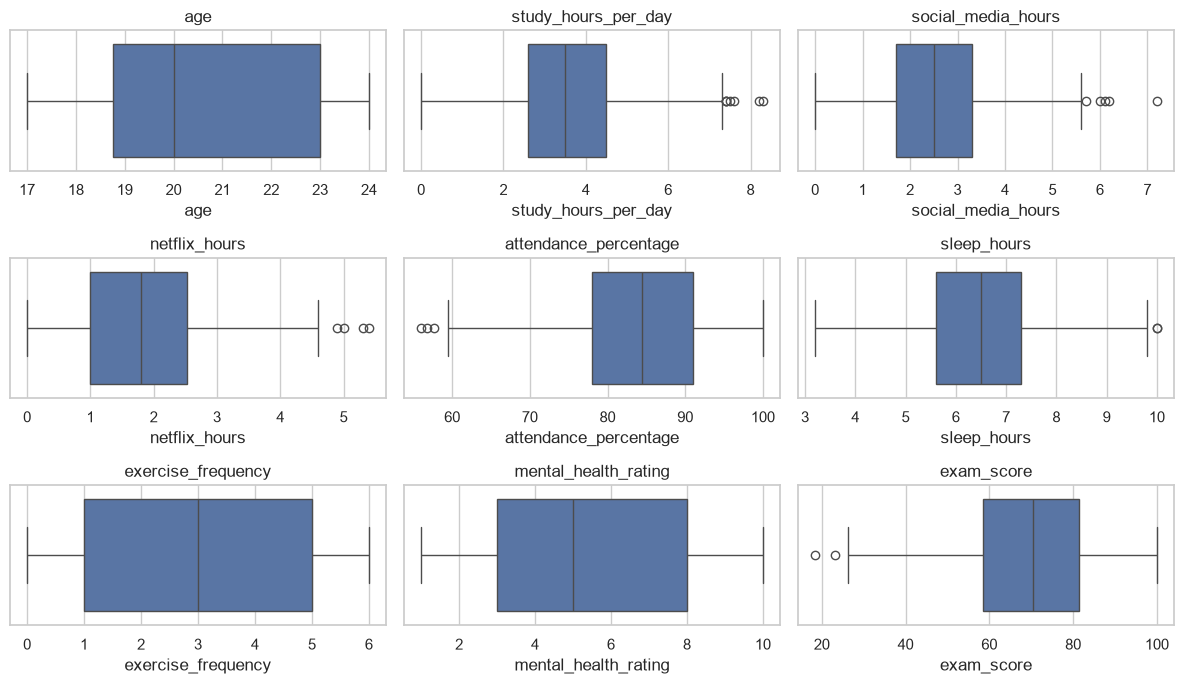

In [197]:
cols = num_cols + [target]
print(len(cols))
fig, axes = plt.subplots(3, 3, figsize = (12,7))
for ax, col in zip(axes.flat, cols):
    sns.boxplot(x = data[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Conclusion**: There are some little outliers, keep its because it is minor

### 2.7. Cleaning decision log

In [198]:
data["parental_education_level"]= data['parental_education_level'].fillna("Unknown")
data['diet_quality_num'] = data['diet_quality'].map({"Poor": 0, "Fair": 1, "Good": 2})
data['internet_quality_num'] = data['internet_quality'].map({"Poor": 0, "Average": 1, "Good": 2})

data.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
diet_quality_num                 0
internet_quality_num             0
dtype: int64

## 3. Univariate Analysis
### 3.1. Target variable

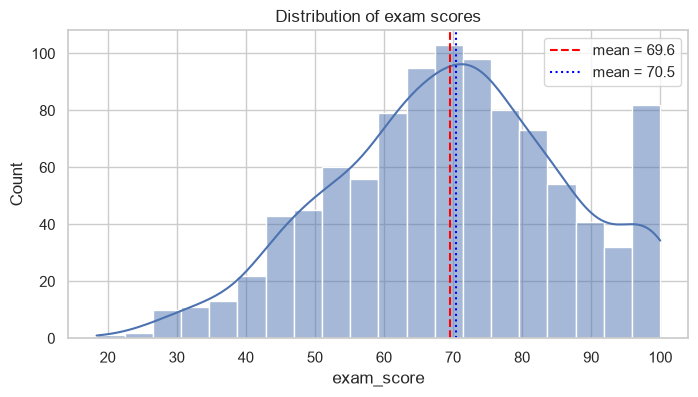

skew:  -0.156 | score = 100: 48


In [199]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data[target],bins=20, kde=True, ax=ax)
ax.axvline(data[target].mean(), color = 'red', ls = '--', label = f'mean = {data[target].mean():.1f}')
ax.axvline(data[target].median(), color = 'blue', ls = ':', label = f'mean = {data[target].median():.1f}')
ax.set_title("Distribution of exam scores")
ax.legend()
plt.show()

print("skew: ", round(data[target].skew(),3), "| score = 100:", (data[target]==100).sum())

**Conclusion**:
- ??
- ???

### 3.2. Numerical features

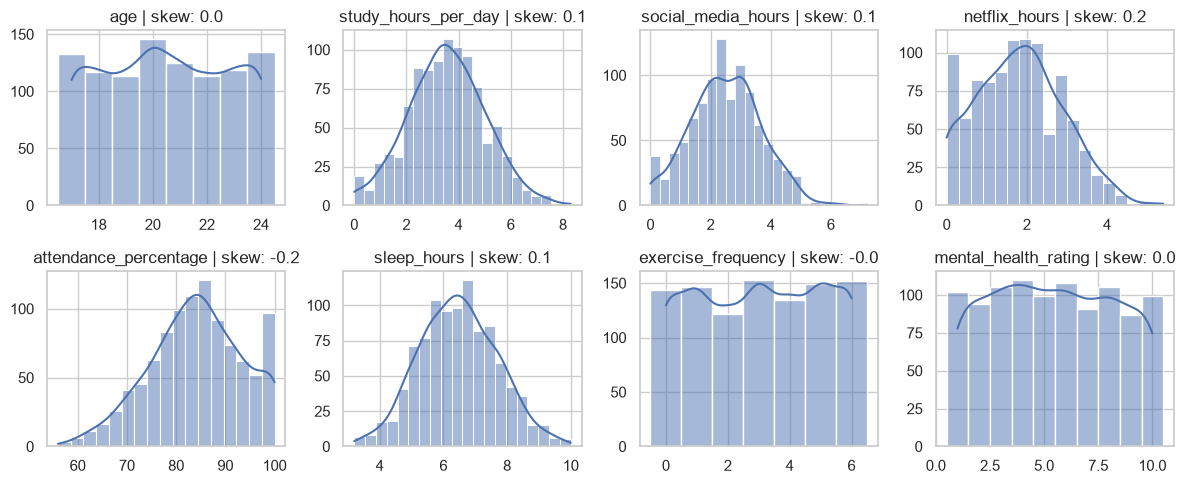

In [200]:
len(num_cols)
fig, axes = plt.subplots(2,4, figsize = (12,5))

for ax, col in zip(axes.flat, num_cols):
    sns.histplot(data = data, x = col, ax = ax, kde = True, discrete=(data[col].dtype == "int64"))
    ax.set_title(f"{col} | skew: {data[col].skew():.1f}" )
    ax.set_ylabel("")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Conclusion**:
- ??
- ???


### 3.3. Categorical features

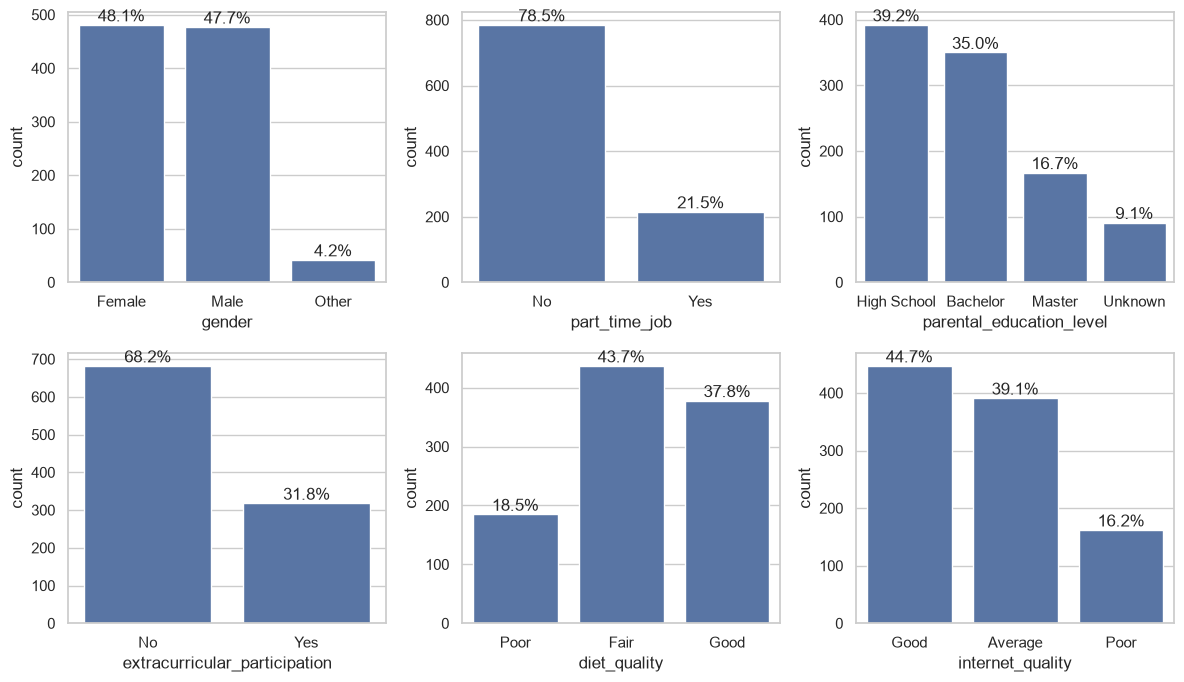

In [201]:
len(cat_cols + ord_cols )

fig, axes = plt.subplots(2, 3, figsize = (12, 7))
for ax, col in zip(axes.flat, cat_cols + ord_cols):
    order = data[col].value_counts().index
    if col == 'diet_quality':
        order = diet_quality_order
    elif col == 'internat_quality':
        order = internet_quality_order

    sns.countplot(data = data, x = col, ax = ax, order=order)
    pct = data[col].value_counts(normalize=True).reindex(order) * 100
    ax.bar_label(ax.containers[0], labels = [f'{p:.1f}%' for p in pct])
plt.tight_layout()
plt.show()

**Conclusion**:
- ??
- ??

## 4. Bivariate Analysis
### 4.1. Numerical features vs target

In [202]:
corr_cols = num_cols + ["internet_quality_num", "diet_quality_num"]
corr_table = pd.DataFrame({
    'pearson': data[corr_cols].corrwith(data[target], method = 'pearson'),
    'spearman': data[corr_cols].corrwith(data[target], method = 'spearman')
})

corr_table.sort_values('spearman',key = abs, ascending= False)


,pearson,spearman
study_hours_per_day,0.825,0.812
mental_health_rating,0.322,0.323
social_media_hours,-0.167,-0.166
netflix_hours,-0.172,-0.165
exercise_frequency,0.160,0.150
sleep_hours,0.122,0.123
attendance_percentage,0.090,0.094
internet_quality_num,-0.036,-0.046
diet_quality_num,0.015,0.014
age,-0.009,-0.010


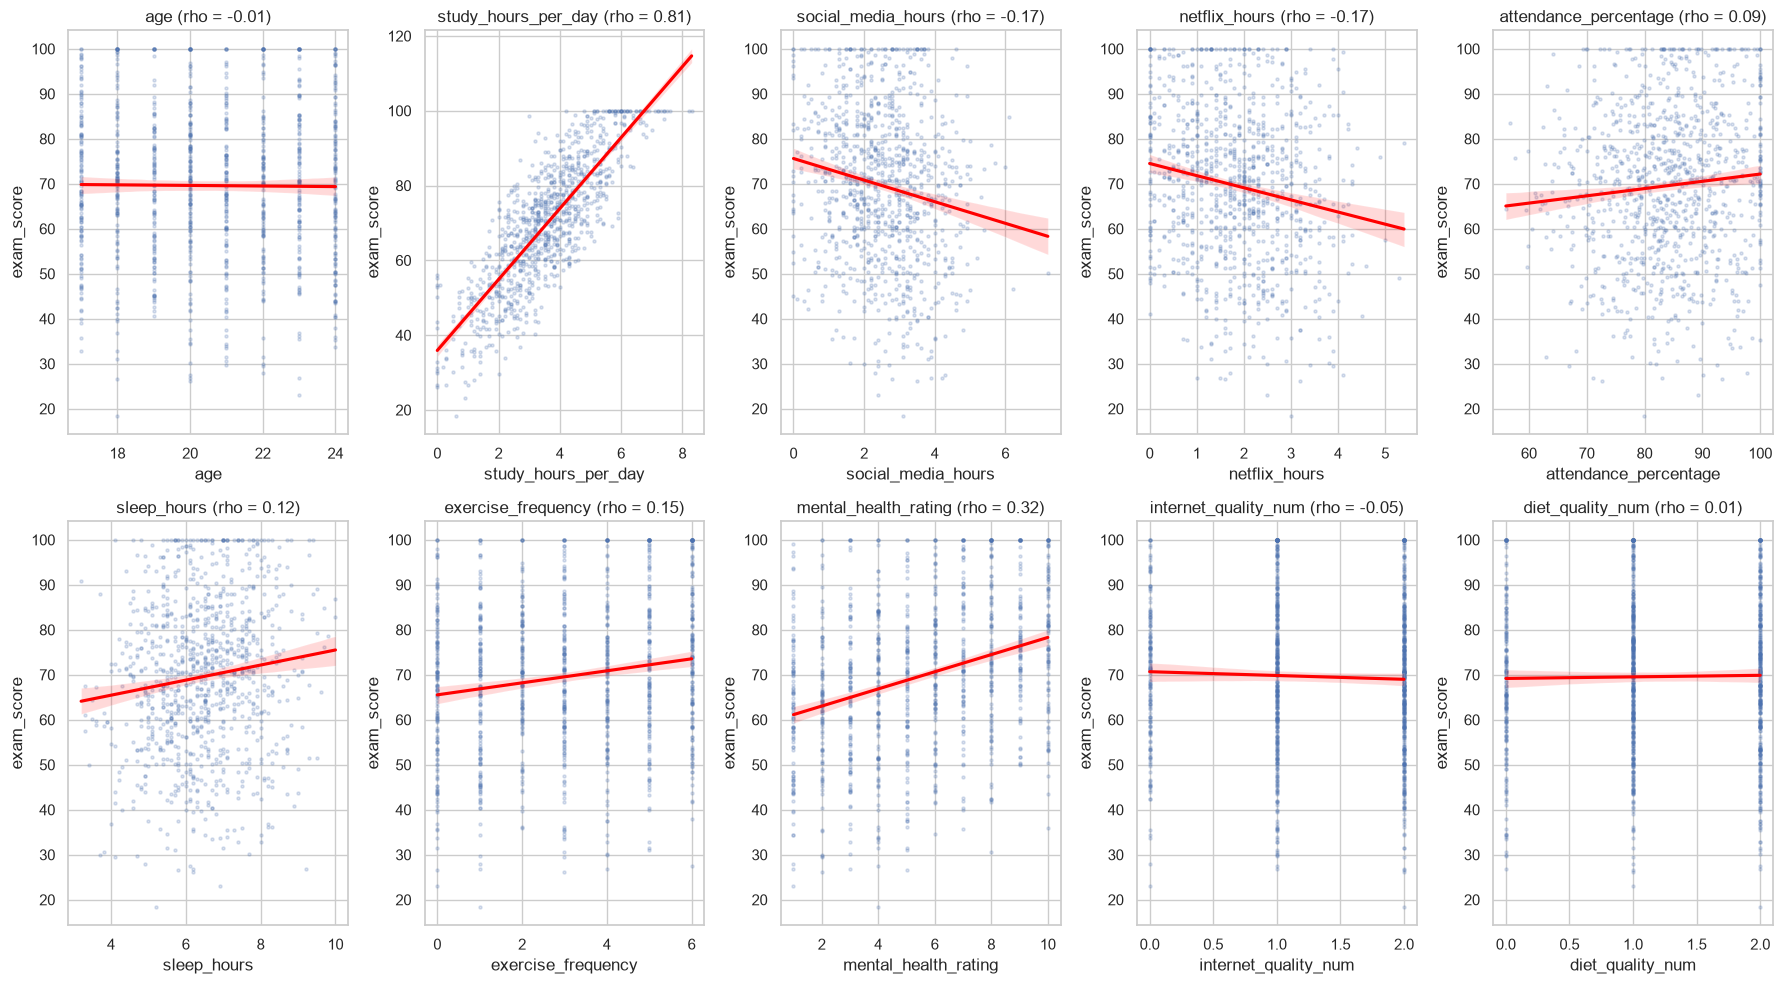

In [203]:
fig, axes = plt.subplots(2, 5, figsize = (18, 10))
for ax, col in zip(axes.flat, corr_cols):
    sns.regplot(data=data, x=col, y=target, ax=ax, scatter_kws={'alpha':0.2, 's':5}, line_kws={'color':'red'})
    ax.set_title(f'{col} (rho = {corr_table.loc[col, "spearman"]:.2f})')

plt.tight_layout()
plt.show()

### 4.2. Categorical features vs target

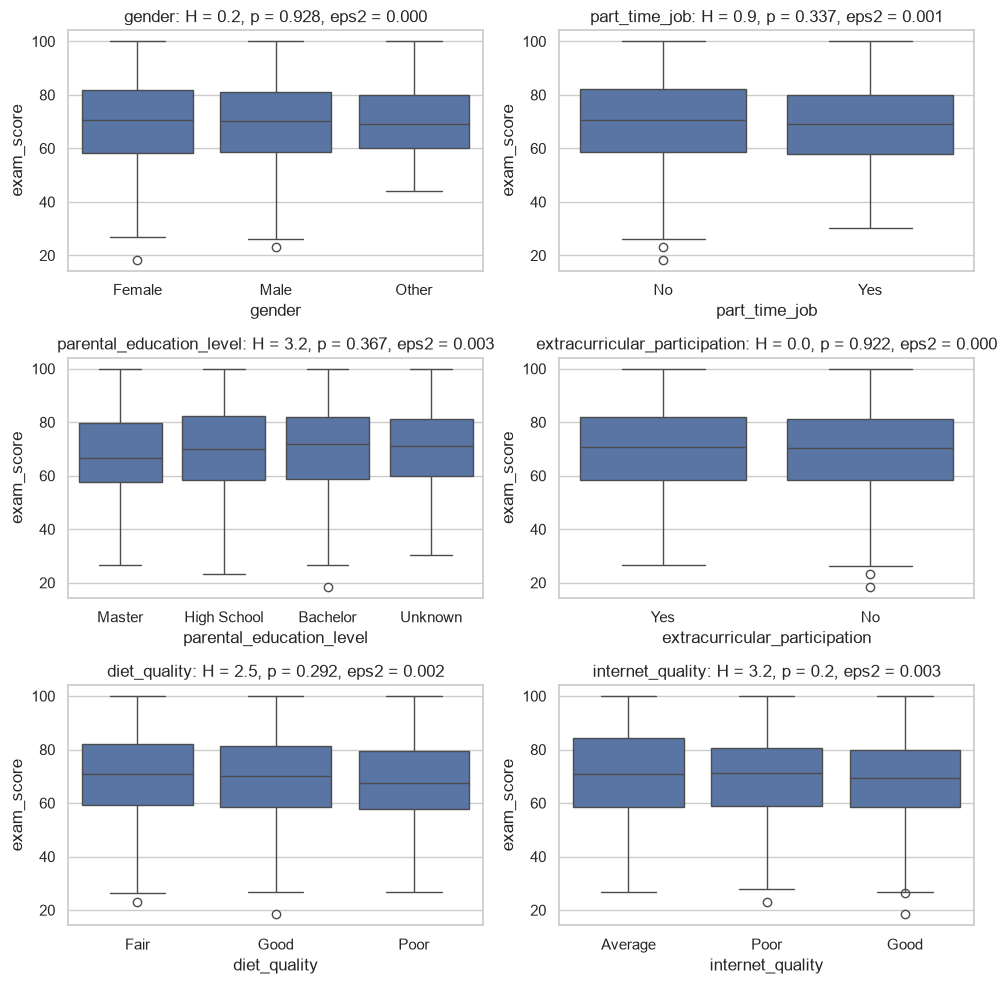

gender {'Female': 70.7, 'Male': 70.2, 'Other': 69.0}
part_time_job {'No': 70.6, 'Yes': 69.2}
parental_education_level {'Bachelor': 71.7, 'High School': 70.0, 'Master': 66.8, 'Unknown': 71.0}
extracurricular_participation {'No': 70.4, 'Yes': 70.6}
diet_quality {'Fair': 71.0, 'Good': 70.3, 'Poor': 67.4}
internet_quality {'Average': 71.0, 'Good': 69.3, 'Poor': 71.4}


In [204]:


fig, axes = plt.subplots(3, 2, figsize= (10,10))
for col, ax in zip(cat_cols + ord_cols, axes.flat):
    sns.boxplot(data = data, x =  col, y=target, ax=ax)
    h, p = stats.kruskal(*[g[target] for _,g in data.groupby(col)])
    eps2 = h / (len(data) - 1)
    ax.set_title(f'{col}: H = {h:.1f}, p = {p:.3g}, eps2 = {eps2:.3f}')
plt.tight_layout()
plt.show()


for col in cat_cols + ord_cols:
    print(col, data.groupby(col)[target].median().round(1).to_dict())

**Conclusion**:
- ??
- ??

## 5. Multivariate Analysis
### 5.1. Correlation matrix

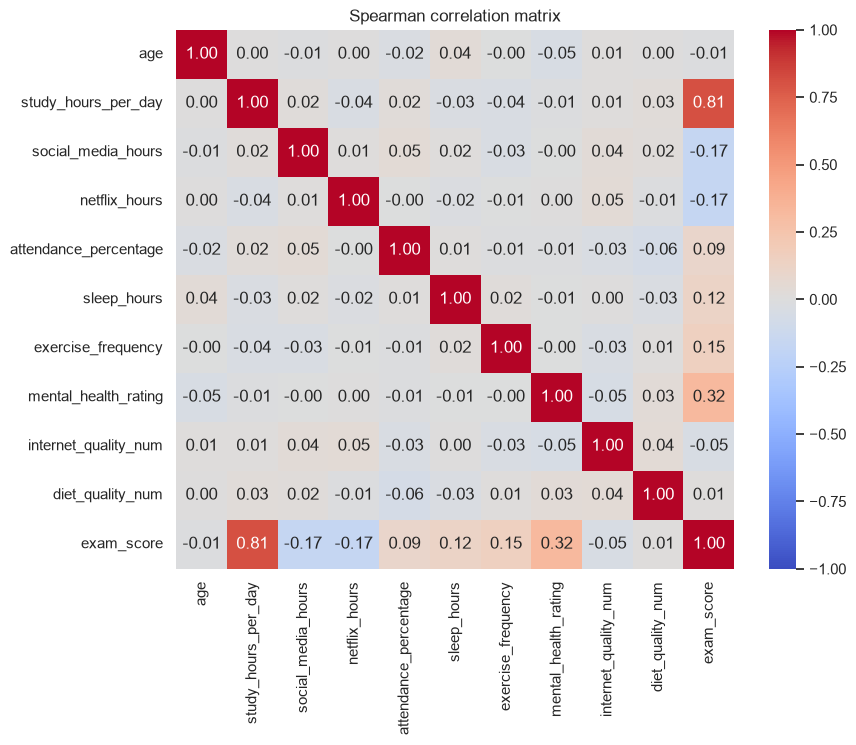

In [205]:
corr = data[corr_cols + [target]].corr(method = 'spearman')
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center = 0, vmin=-1, vmax=1)
plt.title('Spearman correlation matrix')
plt.show()

**Conclusion**:
- ??
- ??

### 5.2. Multicollinearity (VIF)

In [206]:
X = add_constant(data[corr_cols])
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
                index = X.columns).drop('const').sort_values(ascending=False).round(2)
vif.to_frame("VIF")

,VIF
internet_quality_num,1.010
attendance_percentage,1.010
diet_quality_num,1.010
mental_health_rating,1.010
social_media_hours,1.010
study_hours_per_day,1.000
age,1.000
sleep_hours,1.000
exercise_frequency,1.000
netflix_hours,1.000


**Conclusion**:
- ??
- ??